# 02 — Clasificación y análisis con LLM (Ollama)

Clasifica una muestra estratificada de mensajes Conti usando `qwen2.5:14b` local.  
Produce:
- `data/processed/conti_sample_classified.parquet` — muestra con columna `category`
- `data/processed/actor_profiles.json` — perfil de rol inferido por actor


## 0. Setup

In [ ]:
# sys nos permite modificar la configuración del intérprete de Python en tiempo de ejecución.
import sys

# Path para manejar rutas de archivos de forma cómoda y portable.
from pathlib import Path

# Añadimos la carpeta src/ al "path" de Python para poder importar nuestros módulos locales.
# Sin esto, Python no podría encontrar los archivos en src/ cuando hacemos "import loaders".
sys.path.insert(0, str(Path('src').resolve()))

# json para leer y escribir archivos en formato JSON (diccionarios guardados en texto).
import json

# time para medir cuánto tiempo tarda la clasificación con el LLM.
import time

# pandas para trabajar con tablas de datos.
import pandas as pd

# ollama es la librería de Python para hablar con modelos de lenguaje (LLMs)
# que están instalados localmente en el ordenador usando Ollama.
# Ollama permite correr modelos como Qwen, LLaMA o Mistral sin necesitar internet.
import ollama

# tqdm para mostrar barras de progreso durante operaciones largas (clasificar 1500 mensajes).
from tqdm.auto import tqdm

# --- Definición de rutas ---
# Carpeta donde están los datos ya procesados por el notebook 01.
PROCESSED_DIR = Path('../data_Vruto/ContiLeaks')

# Archivo de entrada: el dataset unificado y limpio del notebook 01.
PARQUET_IN      = PROCESSED_DIR / 'conti_unified.parquet'

# Archivo de salida: la muestra de mensajes con su categoría asignada por el LLM.
PARQUET_OUT     = PROCESSED_DIR / 'conti_sample_classified.parquet'

# Archivo de salida: los perfiles de rol de cada actor, en formato JSON.
PROFILES_OUT    = PROCESSED_DIR / 'actor_profiles.json'

# Archivo de checkpoint: guardamos el progreso intermedio para poder reanudar
# si el proceso se interrumpe a mitad. Como clasificar 1500 mensajes tarda minutos,
# es importante no perder el trabajo si algo falla.
CHECKPOINT_PATH = PROCESSED_DIR / 'checkpoint_classified.parquet'

# El modelo de LLM que vamos a usar. qwen2.5:14b es un modelo de lenguaje de
# 14 mil millones de parámetros de la empresa Alibaba, que funciona muy bien con
# texto en ruso y en inglés. Hay que tenerlo descargado con: ollama pull qwen2.5:14b
MODEL = 'qwen2.5:14b'
# OJO, SI NO SE TIENE HAY QUE BAJARLO ANTES: 
# ollama pull nomic-embed-text-v2-moe
#MODEL = 'nomic-embed-text-v2-moe'

# Si PARQUET_OUT y PROFILES_OUT ya existen (p.ej. vinieron precalculados en data_Vruto),
# nos saltamos la clasificación y el perfilado con el LLM más abajo y cargamos
# directamente los resultados ya guardados — así este notebook también se puede
# recorrer entero sin tener Ollama instalado.
ALREADY_DONE = PARQUET_OUT.exists() and PROFILES_OUT.exists()

# Verificamos que el archivo de entrada existe antes de continuar.
# Si no existe, significa que no se ejecutó el notebook 01 primero.
assert PARQUET_IN.exists(), f'No se encuentra {PARQUET_IN} — ejecuta primero el notebook 01'
print('Dependencias OK')

## 1. Cargar dataset unificado

In [2]:
# Cargamos el dataset unificado generado por el notebook 01.
# read_parquet() es mucho más rápido que read_csv() para archivos grandes.
df = pd.read_parquet(PARQUET_IN)

# Mostramos estadísticas básicas para verificar que el archivo se cargó correctamente.
print(f'Mensajes totales : {len(df):,}')
print(f'Actores únicos   : {df.username.nunique()}')

# .date() extrae solo la fecha (sin hora) para mostrarla de forma más compacta.
print(f'Rango temporal   : {df.timestamp.min().date()} → {df.timestamp.max().date()}')
print(f'\nColumnas: {list(df.columns)}')

Mensajes totales : 216,303
Actores únicos   : 485
Rango temporal   : 2020-06-21 → 2022-02-28

Columnas: ['timestamp', 'username', 'to_user', 'message', 'source', 'channel', 'lang']


## 2. Muestreo estratificado por actor

Top 30 actores por volumen × 50 mensajes cada uno = ~1 500 mensajes.  
Muestra distribuida uniformemente en el tiempo (no solo mensajes recientes).

In [3]:
# Cuántos actores incluiremos en el análisis y cuántos mensajes por actor.
# En vez de analizar los 216,000 mensajes (lo que sería muy lento), tomamos
# una muestra representativa: 30 actores × 50 mensajes = 1,500 mensajes total.
TOP_N_ACTORS   = 30
MSGS_PER_ACTOR = 50

# Identificamos los 30 actores con más mensajes en el dataset completo.
# groupby('username').size() cuenta los mensajes de cada usuario.
# sort_values(ascending=False) los ordena de más a menos mensajes.
# head(TOP_N_ACTORS) toma solo los primeros 30.
# .index.tolist() extrae los nombres de usuario como lista de strings.
top_actors = (
    df.groupby('username').size()
    .sort_values(ascending=False)
    .head(TOP_N_ACTORS)
    .index.tolist()
)

def sample_actor(actor_df: pd.DataFrame, n: int) -> pd.DataFrame:
    """
    Selecciona una muestra de n mensajes de un actor, distribuidos uniformemente
    a lo largo del tiempo (no solo los primeros n mensajes, sino uno de cada
    período).

    Por qué esto es mejor que .sample(n): si un actor estuvo activo durante
    2 años, queremos mensajes de todos los períodos, no solo de un momento.

    Parámetros:
        actor_df (DataFrame): Todos los mensajes de un actor.
        n (int): Cuántos mensajes queremos seleccionar.

    Devuelve:
        DataFrame: Los n mensajes seleccionados.
    """
    # Ordenamos los mensajes por fecha para poder dividirlos en períodos cronológicos.
    actor_df = actor_df.sort_values('timestamp').reset_index(drop=True)

    # Si el actor tiene menos mensajes de los que pedimos, devolvemos todos.
    if len(actor_df) <= n:
        return actor_df

    # Calculamos n índices equidistantes a lo largo de la lista de mensajes.
    # Por ejemplo, si hay 200 mensajes y queremos 50, tomamos los índices
    # 0, 4, 8, 12, ... (cada 4 mensajes): int(i * 200 / 50) para i = 0..49
    indices = [int(i * len(actor_df) / n) for i in range(n)]

    # .iloc[indices] selecciona las filas por posición (número de fila).
    return actor_df.iloc[indices]

# Aplicamos el muestreo a cada actor y acumulamos los resultados.
frames = []
for actor in top_actors:
    # Filtramos solo los mensajes del actor actual.
    actor_msgs = df[df['username'] == actor]
    frames.append(sample_actor(actor_msgs, MSGS_PER_ACTOR))

# Unimos todos los DataFrames en uno solo y ordenamos por fecha.
sample = pd.concat(frames, ignore_index=True)
sample = sample.sort_values('timestamp').reset_index(drop=True)

# Verificamos el resultado del muestreo.
print(f'Muestra total: {len(sample):,} mensajes de {sample.username.nunique()} actores')
print('\nMensajes por actor:')
print(sample.groupby('username').size().sort_values(ascending=False).to_string())

Muestra total: 1,500 mensajes de 30 actores

Mensajes por actor:
username
angelo       50
baget        50
bentley      50
bio          50
bloodrush    50
braun        50
defender     50
deploy       50
driver       50
hof          50
kaktus       50
mango        50
marsel       50
mors         50
mushroom     50
price        50
professor    50
revers       50
stern        50
strix        50
target       50
tl1          50
tl2          50
tramp        50
ttrr         50
user4        50
user7        50
user8        50
user9        50
veron        50


## 3. Clasificación de mensajes con qwen2.5:14b

Categorías:
| Categoría | Descripción |
|---|---|
| `technical` | Desarrollo de malware, builds, código, infraestructura |
| `operational` | Ataques, targets, accesos, despliegue |
| `financial` | Pagos, bitcoin, ransom, negociaciones |
| `organizational` | Gestión, tareas, asignaciones, RRHH |
| `comms` | Comunicación general, saludos, off-topic |
| `unknown` | No clasificable (muy corto, sin contexto) |

In [ ]:
# Las categorías posibles para clasificar cada mensaje.
# Usamos un set (conjunto) en vez de lista porque los sets son más rápidos
# para verificar si un elemento pertenece a ellos (operación "in").
CATEGORIES = {'technical', 'operational', 'financial', 'organizational', 'comms', 'unknown'}

# El "system prompt" es la instrucción que le damos al LLM para definir su comportamiento.
# Le explicamos el contexto (analista de amenazas clasificando chats de Conti),
# las categorías posibles y el formato de respuesta esperado.
# Esta parte es crucial: la calidad del system prompt determina la calidad de la clasificación.
SYSTEM_PROMPT = """You are a threat intelligence analyst classifying messages from the leaked Conti ransomware group chats.
Messages are mostly in Russian. Classify each message into exactly one category:
- technical: malware development, builds, code, infrastructure, bugs, tools
- operational: attacks, targets, victims, accesses, deployment, reconnaissance
- financial: payments, bitcoin, ransom negotiations, money, commissions
- organizational: management, task assignments, team structure, HR, recruitment
- comms: general conversation, greetings, scheduling, off-topic
- unknown: too short or ambiguous to classify

Reply with ONLY the category name, nothing else."""

def classify_message(text: str) -> str:
    """
    Clasifica un mensaje de chat de Conti en una de las 6 categorías predefinidas
    usando el LLM local (qwen2.5:14b via Ollama).

    Parámetros:
        text (str): El texto del mensaje a clasificar.

    Devuelve:
        str: Una de las 6 categorías: 'technical', 'operational', 'financial',
             'organizational', 'comms' o 'unknown'.
    """
    # Si el mensaje tiene menos de 5 caracteres, es demasiado corto para clasificar.
    if len(text.strip()) < 5:
        return 'unknown'

    try:
        # Llamamos al LLM a través de Ollama. Le enviamos dos mensajes:
        # 1. El "system" con las instrucciones de rol y formato.
        # 2. El "user" con el mensaje a clasificar.
        # temperature=0 → respuestas deterministas (siempre la misma respuesta para el mismo texto)
        # num_predict=10 → el modelo solo puede generar 10 tokens (suficiente para una palabra)
        resp = ollama.chat(
            model=MODEL,
            messages=[
                {'role': 'system', 'content': SYSTEM_PROMPT},
                {'role': 'user',   'content': f'Message: {text[:400]}'}
            ],
            options={'temperature': 0, 'num_predict': 10}
        )

        # Procesamos la respuesta del modelo:
        # .content → el texto generado por el modelo
        # .strip() → elimina espacios al inicio y al final
        # .lower() → convertimos a minúsculas (por si el modelo responde "Technical")
        # .split()[0] → tomamos solo la primera palabra (por si escribe algo extra)
        # .rstrip('.,:') → eliminamos puntuación al final de la palabra
        raw = resp.message.content.strip().lower().split()[0].rstrip('.,:')

        # Si la palabra que devuelve el modelo es una categoría válida, la devolvemos.
        # Si no (el modelo "se inventó" algo), devolvemos 'unknown'.
        return raw if raw in CATEGORIES else 'unknown'
    except Exception:
        # Si algo falla (timeout, error de conexión con Ollama, etc.), devolvemos 'unknown'.
        return 'unknown'

# Probamos la función con un ejemplo antes de usarla en masa.
# Nos saltamos esta prueba si ya tenemos los resultados en caché — no hace falta
# tener Ollama levantado si no vamos a clasificar nada nuevo.
if not ALREADY_DONE:
    print('Función de clasificación lista. Ejemplo:')
    test = classify_message('Нужно собрать новый билд для x64')
    print(f'  "Нужно собрать новый билд для x64" → {test}')

In [ ]:
if not ALREADY_DONE:
    # Verificamos si existe un checkpoint de una ejecución anterior.
    # Un checkpoint nos permite reanudar el proceso de clasificación desde donde se quedó
    # si el notebook fue interrumpido (por ejemplo, si el ordenador se apagó o Ollama falló).
    if CHECKPOINT_PATH.exists():
        # Si existe el checkpoint, lo cargamos y obtenemos los índices ya procesados.
        done = pd.read_parquet(CHECKPOINT_PATH)
        done_ids = set(done.index)  # set() para búsquedas rápidas
        print(f'Checkpoint encontrado: {len(done):,} mensajes ya clasificados')
    else:
        # Si no hay checkpoint, empezamos desde cero.
        done = pd.DataFrame()
        done_ids = set()
        print('Sin checkpoint previo — comenzando desde cero')

    # Filtramos la muestra para quedarnos solo con los mensajes que NO están ya clasificados.
    # ~ es el operador "NOT" en pandas: invierte la máscara booleana.
    # .isin(done_ids) devuelve True para los índices ya procesados.
    todo = sample[~sample.index.isin(done_ids)].copy()
    print(f'Pendientes: {len(todo):,} mensajes')
else:
    print(f'{PARQUET_OUT} ya existe — se cargará directamente en la siguiente celda, sin clasificar.')

In [ ]:
if not ALREADY_DONE:
    # Guardamos un checkpoint cada CHECKPOINT_EVERY mensajes para no perder progreso.
    CHECKPOINT_EVERY = 50  # guardar progreso cada N mensajes

    # Lista donde acumulamos los resultados de clasificación.
    results = []

    # Guardamos el tiempo de inicio para calcular cuánto tardó al final.
    t0 = time.time()

    # Iteramos sobre cada mensaje pendiente de clasificar.
    # tqdm() envuelve el iterador y muestra la barra de progreso.
    # todo.iterrows() devuelve pares (índice, fila) para cada mensaje.
    for i, (idx, row) in enumerate(tqdm(todo.iterrows(), total=len(todo), desc='Clasificando')):
        # Llamamos al LLM para clasificar este mensaje.
        cat = classify_message(row['message'])

        # Guardamos el resultado junto con el índice original del mensaje.
        results.append({'idx': idx, 'category': cat})

        # Cada CHECKPOINT_EVERY mensajes, guardamos el progreso en disco.
        if (i + 1) % CHECKPOINT_EVERY == 0:
            # Creamos un DataFrame con los resultados acumulados hasta ahora.
            chunk = pd.DataFrame(results).set_index('idx')

            # Combinamos los mensajes ya clasificados (done) con los nuevos (chunk).
            # .assign(category=...) añade la columna de categoría a los mensajes de la muestra.
            partial = pd.concat([done, sample.loc[chunk.index].assign(category=chunk['category'])])
            partial.to_parquet(CHECKPOINT_PATH)

    # Calculamos el tiempo total transcurrido.
    elapsed = time.time() - t0
    print(f'\nClasificación completada en {elapsed/60:.1f} min ({elapsed/max(len(todo),1):.1f} s/msg)')

    # --- Combinar los resultados nuevos con el checkpoint anterior (si existía) ---
    # Creamos un DataFrame con los resultados nuevos, usando el índice original.
    new_df = pd.DataFrame(results).set_index('idx')

    # Recuperamos los mensajes originales correspondientes a los índices clasificados.
    sample_new = sample.loc[new_df.index].copy()

    # Añadimos la columna de categoría con los resultados del LLM.
    sample_new['category'] = new_df['category'].values

    # Combinamos con los mensajes que ya estaban clasificados en el checkpoint (si había).
    # sort_values ordena por fecha y reset_index renumera las filas.
    classified = pd.concat([done, sample_new]).sort_values('timestamp').reset_index(drop=True)
    print(f'Total clasificados: {len(classified):,}')
else:
    # Ya tenemos el resultado final en disco — lo cargamos directamente en vez
    # de volver a clasificar mensaje a mensaje con el LLM.
    classified = pd.read_parquet(PARQUET_OUT)
    print(f'Cargados {len(classified):,} mensajes ya clasificados desde caché.')

## 4. Análisis de resultados

In [7]:
# Importamos matplotlib y numpy para crear visualizaciones.
import matplotlib.pyplot as plt
import matplotlib.cm as cm  # cm = color maps (paletas de colores predefinidas)
import numpy as np

# Mostramos la distribución global de categorías para ver qué tipo de mensajes
# tiene la muestra. Esto nos da una idea del perfil general de comunicación de Conti.
print('=== Distribución global de categorías ===')

# value_counts() cuenta cuántos mensajes hay en cada categoría.
cat_counts = classified['category'].value_counts()
print(cat_counts.to_string())

# También mostramos los porcentajes dividiendo entre el total y multiplicando por 100.
# .round(1) redondea a 1 decimal.
print(f'\n{(cat_counts / len(classified) * 100).round(1).to_string()} %')

=== Distribución global de categorías ===
category
unknown    1500

category
unknown    100.0 %


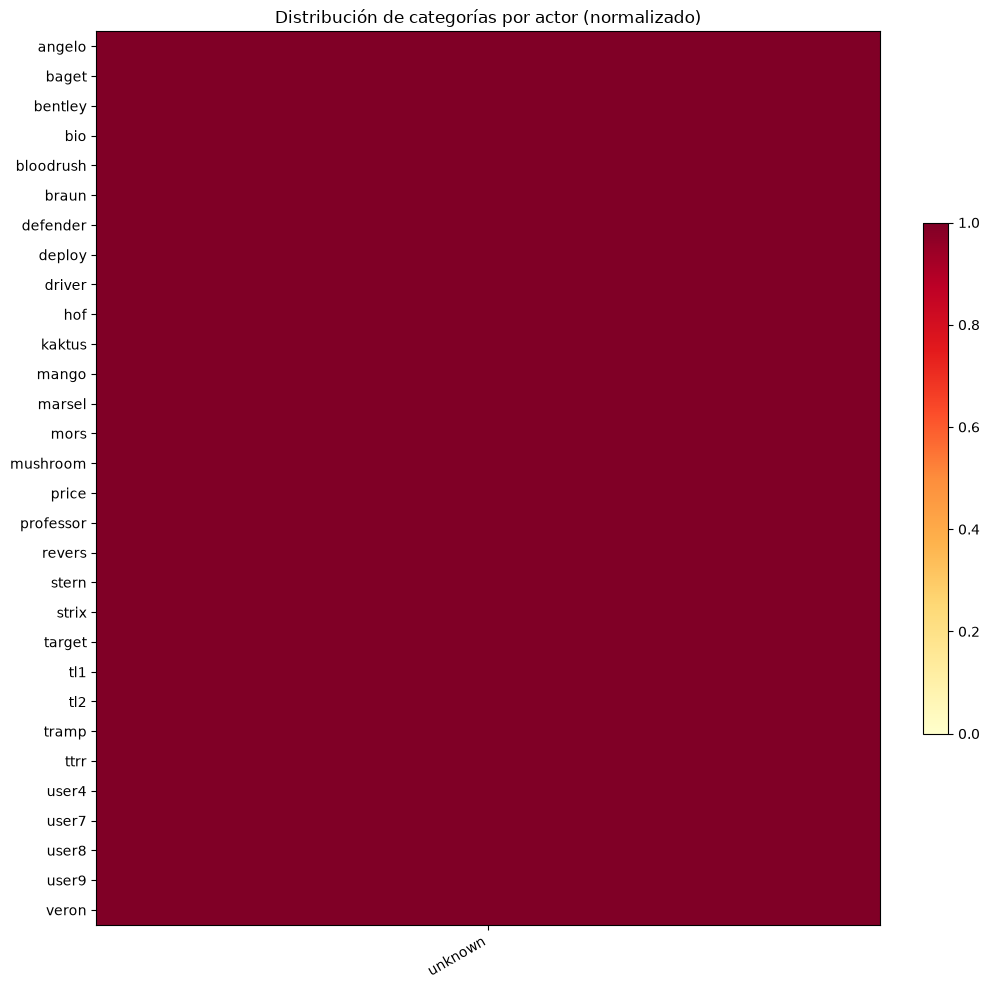

In [8]:
# Creamos un heatmap (mapa de calor) que muestra, para cada actor,
# qué proporción de sus mensajes pertenece a cada categoría.
# Esto nos permite ver de un vistazo quién es más "técnico", quién más "operacional", etc.

# Creamos una tabla pivot: filas = actores, columnas = categorías, valores = número de mensajes.
# groupby(['username', 'category']).size() cuenta mensajes por (actor, categoría).
# .unstack() convierte el nivel de categoría en columnas.
# fill_value=0 rellena con 0 los casos en que un actor no tiene mensajes de alguna categoría.
pivot = (
    classified.groupby(['username', 'category']).size()
    .unstack(fill_value=0)
)

# Normalizamos los valores dividiendo cada fila entre el total de mensajes de ese actor.
# Esto convierte los conteos en proporciones (valores entre 0 y 1).
# .div(pivot.sum(axis=1), axis=0) divide cada fila entre su suma total.
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

# Ordenamos las columnas según el orden lógico de categorías (de más técnico a más general).
cat_order = ['technical', 'operational', 'financial', 'organizational', 'comms', 'unknown']

# Nos quedamos solo con las categorías que realmente aparecen en los datos.
cat_order = [c for c in cat_order if c in pivot_norm.columns]
pivot_norm = pivot_norm[cat_order]

# Ordenamos los actores agrupando los que tienen la misma categoría dominante.
# idxmax(axis=1) devuelve, para cada actor, la categoría con mayor proporción.
# sort_values() ordena los actores por su categoría dominante (alfabéticamente).
# .index obtiene los nombres de los actores en ese orden.
pivot_norm = pivot_norm.loc[pivot_norm.idxmax(axis=1).sort_values().index]

# Creamos el heatmap con matplotlib.
fig, ax = plt.subplots(figsize=(10, 10))

# imshow muestra una matriz de valores como un mapa de colores.
# YlOrRd es una paleta que va de amarillo (0) a rojo (1).
# vmin=0, vmax=1 establece la escala de colores de 0% a 100%.
im = ax.imshow(pivot_norm.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)

# Configuramos las etiquetas del eje X (categorías).
ax.set_xticks(range(len(cat_order)))
ax.set_xticklabels(cat_order, rotation=30, ha='right')

# Configuramos las etiquetas del eje Y (actores).
ax.set_yticks(range(len(pivot_norm)))
ax.set_yticklabels(pivot_norm.index)

ax.set_title('Distribución de categorías por actor (normalizado)')

# Añadimos una barra de colores a la derecha que explica la escala.
# fraction=0.03 controla el ancho de la barra.
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()

In [9]:
# Mostramos ejemplos reales de mensajes de cada categoría para validar visualmente
# que la clasificación del LLM tiene sentido. Es importante hacer esta revisión manual
# antes de confiar en los resultados automatizados.

# Recorremos todas las categorías excepto 'unknown' (que no aporta información relevante).
for cat in cat_order[:-1]:  # excluir 'unknown'
    # Seleccionamos 3 mensajes aleatorios de esta categoría.
    # min(3, ...) asegura que no pedimos más mensajes de los que hay.
    # random_state=42 hace que la selección sea reproducible (siempre los mismos mensajes).
    examples = classified[classified['category'] == cat]['message'].sample(
        min(3, (classified['category'] == cat).sum()), random_state=42
    ).tolist()

    print(f'\n=== {cat.upper()} ===')
    for ex in examples:
        # Mostramos solo los primeros 120 caracteres de cada mensaje para que quepan en pantalla.
        print(f'  • {ex[:120]}')

## 5. Perfilado de actores

Para cada top actor: enviamos un lote de sus mensajes clasificados y pedimos al LLM que infiera su rol en la organización.

In [ ]:
# El "system prompt" para el perfilado de actores. En vez de clasificar mensajes individuales,
# ahora le pedimos al LLM que lea un lote de mensajes de un actor y deduzca su rol
# dentro de la organización criminal Conti.
# Le pedimos que responda en formato JSON con campos específicos para poder
# procesar la respuesta fácilmente con código.
PROFILE_SYSTEM = """You are a threat intelligence analyst studying the Conti ransomware group.
Given a sample of messages from one member, infer their role in the organization.

Reply in JSON with these fields:
{
  "role": "<one of: leader, developer, operator, negotiator, affiliate, support, unknown>",
  "confidence": "<high|medium|low>",
  "summary": "<2-3 sentences in English describing their responsibilities>",
  "evidence": ["<quote or paraphrase from messages, max 3>"]
}"""

def profile_actor(actor: str, messages: list[str]) -> dict:
    """
    Usa el LLM para inferir el rol de un actor dentro de Conti a partir de
    una muestra de sus mensajes.

    Parámetros:
        actor (str): El nombre de usuario (alias) del actor.
        messages (list[str]): Lista de mensajes enviados por ese actor.

    Devuelve:
        dict: Un diccionario con los campos 'role', 'confidence', 'summary'
              y 'evidence'. Si hay algún error, devuelve un diccionario con
              rol 'unknown' y nivel de confianza 'low'.
    """
    # Construimos el bloque de texto con los mensajes del actor.
    # Tomamos máximo 30 mensajes para no exceder el límite de tokens del LLM.
    # Cada mensaje aparece como un punto de lista (- mensaje).
    # [:200] limita cada mensaje a 200 caracteres.
    msg_block = '\n'.join(f'- {m[:200]}' for m in messages[:30])

    # El mensaje de usuario incluye el nombre del actor y sus mensajes.
    user_msg  = f'Actor: {actor}\n\nMessages:\n{msg_block}'

    try:
        # Llamamos al LLM con temperatura 0.1 (ligeramente aleatoria para mayor variedad)
        # y num_predict=300 (suficiente para generar el JSON completo con la descripción).
        resp = ollama.chat(
            model=MODEL,
            messages=[
                {'role': 'system', 'content': PROFILE_SYSTEM},
                {'role': 'user',   'content': user_msg}
            ],
            options={'temperature': 0.1, 'num_predict': 300}
        )
        raw = resp.message.content.strip()

        # El LLM a veces añade texto antes o después del JSON.
        # Buscamos la posición de la primera llave abierta '{' y la última cerrada '}'.
        # Esto nos permite extraer solo el JSON aunque haya texto alrededor.
        start = raw.find('{')
        end   = raw.rfind('}') + 1  # +1 porque rfind da el índice de '}', necesitamos el siguiente

        # json.loads convierte el texto JSON en un diccionario Python.
        return json.loads(raw[start:end])
    except Exception as e:
        # Si algo falla (JSON malformado, error de conexión, etc.), devolvemos un perfil vacío.
        return {'role': 'unknown', 'confidence': 'low', 'summary': str(e), 'evidence': []}

# Probamos la función con el primer actor de la lista antes de aplicarla a todos.
# Nos saltamos esta prueba si ya tenemos los perfiles en caché.
if not ALREADY_DONE:
    print('Función de perfilado lista. Probando con un actor...')
    test_actor = top_actors[0]
    test_msgs  = classified[classified['username'] == test_actor]['message'].tolist()
    test_profile = profile_actor(test_actor, test_msgs)
    print(f'\nActor: {test_actor}')
    # json.dumps convierte el diccionario a texto JSON con formato bonito (indent=2 = 2 espacios).
    # ensure_ascii=False permite mostrar caracteres no-ASCII (como el ruso) sin escape.
    print(json.dumps(test_profile, indent=2, ensure_ascii=False))

In [ ]:
if not ALREADY_DONE:
    # Aplicamos el perfilado a todos los actores del top 30.
    # Esto tarda aproximadamente 2 minutos (unos 4 segundos por actor).
    actor_profiles = {}

    for actor in tqdm(top_actors, desc='Perfilando actores'):
        # Obtenemos todos los mensajes de este actor de la muestra clasificada.
        msgs = classified[classified['username'] == actor]['message'].tolist()

        # Llamamos al LLM para inferir su rol y guardamos el perfil.
        actor_profiles[actor] = profile_actor(actor, msgs)

    # Mostramos un resumen de los roles inferidos para todos los actores.
    # Esto es un primer vistazo rápido al organigrama inferido de Conti.
    print('\n=== ROLES INFERIDOS ===')
    for actor, profile in actor_profiles.items():
        role = profile.get('role', '?')      # Rol inferido por el LLM
        conf = profile.get('confidence', '?') # Confianza del LLM en su inferencia
        summ = profile.get('summary', '')[:80] # Resumen breve (primeros 80 caracteres)

        # Usamos formateo de cadenas alineado: :<15 alinea a la izquierda en 15 caracteres.
        print(f'  {actor:<15} [{role:<15}] ({conf:<6}) — {summ}')
else:
    # Ya tenemos los perfiles en disco — los cargamos directamente en vez de
    # volver a perfilar actor a actor con el LLM.
    with open(PROFILES_OUT, encoding='utf-8') as f:
        actor_profiles = json.load(f)
    print(f'Cargados {len(actor_profiles):,} perfiles de actores desde caché.')

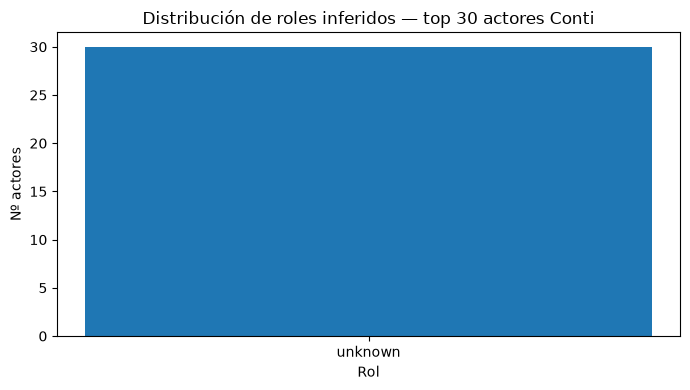

In [12]:
# Visualizamos la distribución de roles inferidos como un gráfico de barras.
# Counter cuenta cuántos actores tienen cada rol.
from collections import Counter

# Extraemos el rol de cada perfil. .get('role', 'unknown') devuelve 'unknown'
# si el perfil no tiene la clave 'role' (lo que indicaría un error en la inferencia).
roles = [p.get('role', 'unknown') for p in actor_profiles.values()]

# Counter es como un diccionario que cuenta ocurrencias: {'operator': 20, 'developer': 6, ...}
role_counts = Counter(roles)

# Creamos un gráfico de barras con los roles en el eje X y el número de actores en el eje Y.
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(role_counts.keys(), role_counts.values())
ax.set_title('Distribución de roles inferidos — top 30 actores Conti')
ax.set_ylabel('Nº actores')
ax.set_xlabel('Rol')
plt.tight_layout()
plt.show()

## 6. Guardar

In [ ]:
if ALREADY_DONE:
    print(f'Ya existen, no se regeneran: {PARQUET_OUT.name}, {PROFILES_OUT.name}')
else:
    # Guardamos los mensajes clasificados en formato Parquet para el notebook siguiente.
    classified.to_parquet(PARQUET_OUT, index=False)
    print(f'Muestra clasificada → {PARQUET_OUT}  ({PARQUET_OUT.stat().st_size/1024:.0f} KB)')

    # Guardamos los perfiles de actores en formato JSON.
    # json.dump escribe el diccionario Python en el archivo como texto JSON.
    # indent=2 → formato legible con sangría de 2 espacios
    # ensure_ascii=False → permite caracteres no-ASCII (como texto en ruso en los perfiles)
    with open(PROFILES_OUT, 'w', encoding='utf-8') as f:
        json.dump(actor_profiles, f, indent=2, ensure_ascii=False)
    print(f'Perfiles de actores → {PROFILES_OUT}')

    # Eliminamos el archivo de checkpoint porque ya terminamos.
    # El checkpoint ya no es necesario y ocuparía espacio innecesariamente.
    # .unlink() es el equivalente de "borrar archivo" en Path.
    if CHECKPOINT_PATH.exists():
        CHECKPOINT_PATH.unlink()
        print('Checkpoint eliminado')

# Mostramos un resumen final de lo que se produjo en este notebook.
print('\n=== RESUMEN FINAL ===')
print(f'  Mensajes clasificados : {len(classified):,}')
print(f'  Actores perfilados    : {len(actor_profiles)}')
print(f'  Categorías            : {classified["category"].value_counts().to_dict()}')